# Cross-Selling Assicurativo

In [ ]:
# libraries import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, log_loss, accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import RocCurveDisplay
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
import warnings
warnings.filterwarnings("ignore")
sns.set_theme()

In [ ]:
# data import
df = pd.read_csv("https://proai-datasets.s3.eu-west-3.amazonaws.com/insurance_cross_sell.csv")
df = df.drop('id', axis=1)
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


## Funzioni utili

In [ ]:
def categ_counts_response(var):
    '''
    Print the category percentages of the specified variable (var), overall and by Response.
    Then print the countplot of the variable by Response.
    '''
    print(f'Count of {var} [%]')
    print('---------------------------')
    print(round(df[var].value_counts(normalize=True)*100, 1))
    print(f'\nCount of {var} vs Response')
    print('---------------------------')
    print(round(pd.crosstab(df[var],df['Response'], normalize='index')*100, 1))
    sns.countplot(x=df[var], hue=df['Response'])
    plt.show()


def mapping_cat(col, top_categories):
    '''
    Return the column of the dataframe mapped to maintain only the categories specified in top_categories and grouping the others in a new category named "other"

    x: the column to map
    top_categories (list): list of categories to maintain

    '''
    return col.where(col.isin(top_categories), "altro")


def plot_confusion_matrix(y_true, y_pred, labels=["Negative", "Positive"]):
  '''
  Plot the confusion matrix for the given true and predicted labels.
  '''

  cm = confusion_matrix(y_true, y_pred) # tn, fp, fn, tp

  df_cm = pd.DataFrame(cm, index = labels,
                    columns = ["Predicted "+labels[0],"Predicted "+labels[1]])
  sns.heatmap(df_cm, annot=True, fmt='g')

## Esplorazione del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                381109 non-null  object 
 1   Age                   381109 non-null  int64  
 2   Driving_License       381109 non-null  int64  
 3   Region_Code           381109 non-null  float64
 4   Previously_Insured    381109 non-null  int64  
 5   Vehicle_Age           381109 non-null  object 
 6   Vehicle_Damage        381109 non-null  object 
 7   Annual_Premium        381109 non-null  float64
 8   Policy_Sales_Channel  381109 non-null  float64
 9   Vintage               381109 non-null  int64  
 10  Response              381109 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 32.0+ MB


Variabili categoriche:
- Gender
- Driving_License: 1 o 0
- Region_code: 53 categorie
- Previously_Insured: 1 o 0
- Vehicle_Age: codificata in 3 categorie
- Vehicle_Damage: 1 o 0
- Policy_Sales_Channel: 155 categorie
- Response: 1 o 0

Variabili continue:
- Age
- Annual_Premium
- Vintage


Si verifica l'eventuale presenza di valori mancanti.

In [ ]:
df.isna().sum()

,0
Gender,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Vehicle_Damage,0
Annual_Premium,0
Policy_Sales_Channel,0
Vintage,0


### Variabili quantitative

Si osservano le statistiche delle variabili quantitative

In [ ]:
cont_var = ['Age', 'Annual_Premium', 'Vintage']
round(df[cont_var].describe(), 2)

,Age,Annual_Premium,Vintage
count,381109.00,381109.00,381109.00
mean,38.82,30564.39,154.35
std,15.51,17213.16,83.67
min,20.00,2630.00,10.00
25%,25.00,24405.00,82.00
50%,36.00,31669.00,154.00
75%,49.00,39400.00,227.00
max,85.00,540165.00,299.00


L'età degli assicurati è compresa tra i 20 e gli 85 anni con una media di 38 anni.  
Il premio annuale va da 2630 a 540165 con una media di 30564. Il 75% dei dati è però inferiore a 39400, il che mostra una presenza di molti valori estremi verso l'alto: la distribuzione di questa variabile sarà probabilmente scodata verso valori alti.  
I soggetti sono assicurati in media da 154 giorni.

Si osservano le distribuzioni delle variabili quantitative

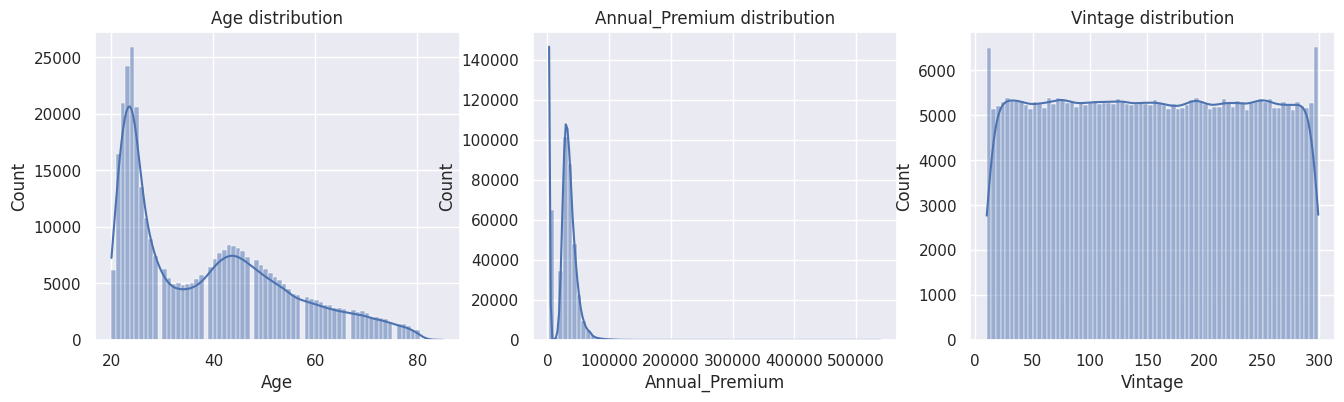

In [ ]:
plt.figure(figsize=(16,4))

for i, var in enumerate(cont_var):
    plt.subplot(1, 3, i+1)
    sns.histplot(x =df[var], bins=72, kde=True)
    plt.title(f'{var} distribution')

plt.show()


Sia l'età sia il premio annuale risultano avere delle distrubuzioni asimmetriche, mentre la variabile vintage ha una distribuzione simmetrica.  


### Variabili categoriche

Si osservano le distribuzioni di alcune variabili categoriche

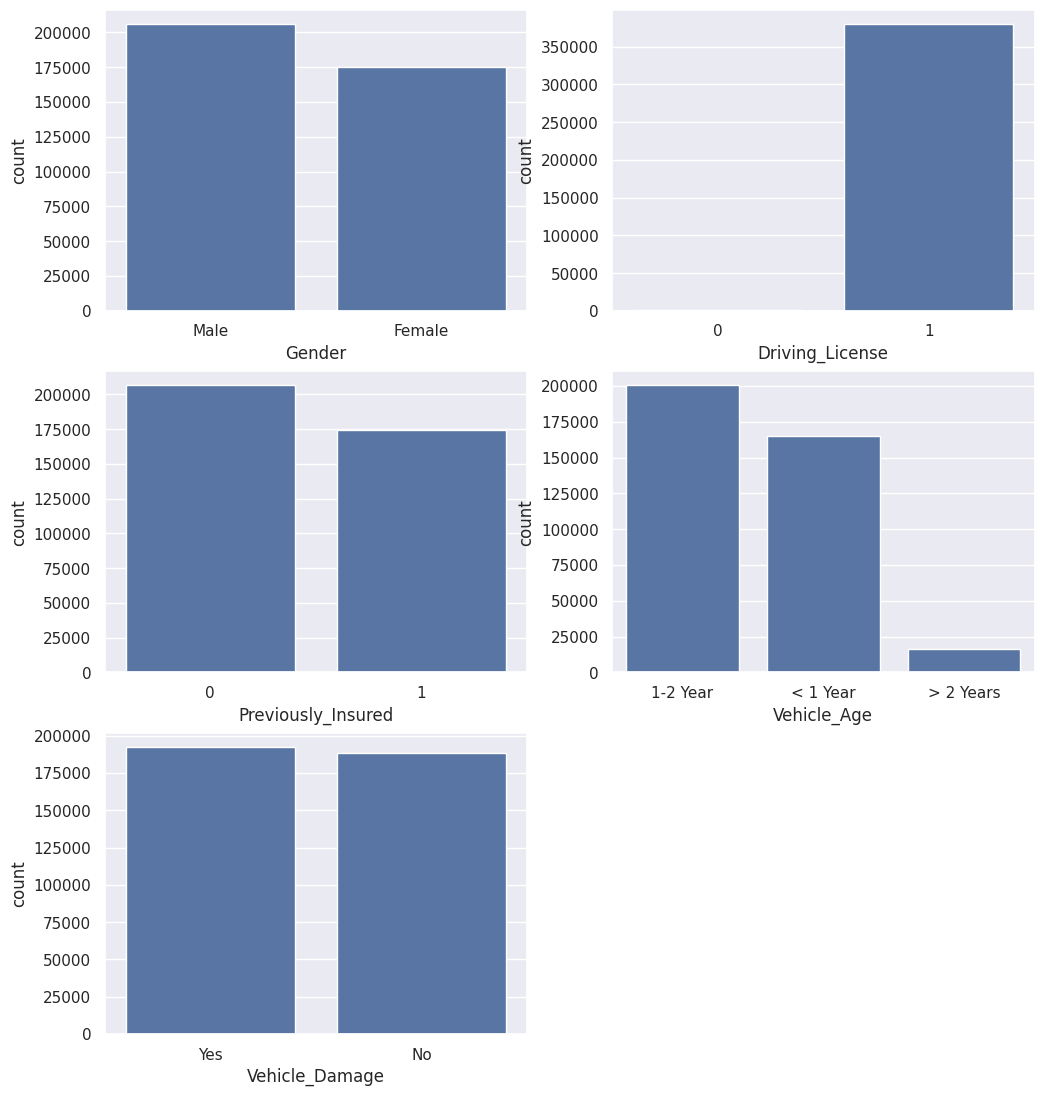

In [ ]:
category_var_mask = ['Gender', 'Driving_License', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage']

plt.figure(figsize=(12,18))

for i,var in enumerate(category_var_mask):
    plt.subplot(4,2,i+1)
    sns.barplot(df[var].value_counts())
plt.show()

Le variabili Gender, Previously_Insured e Vehicle_Damage sono abbastanza bilanciate.  
La variabile Driving_License è sbilanciata in quanto chi assicura un veicolo normalmente ha la patente di guida.  
La variabile Vehicle_Age ha una preponderanza di osservazioni relative ad auto di 1-2 anni, intermedia relative ad auto di età inferiore a 1 anno e poche osservazioni relative ad auto superiori ai 2 anni.

Si osserva ora la distribuzione della variabile Response

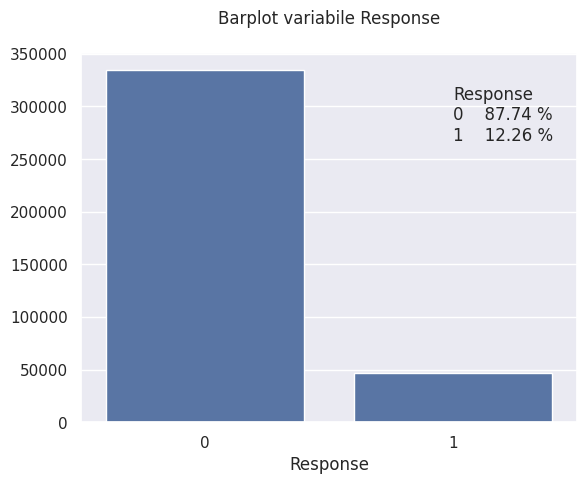

In [ ]:
counts = df['Response'].value_counts()
ax = sns.barplot(x=counts.index, y=counts.values)
heights = [patch.get_height() for patch in ax.patches]
plt.text(1, max(heights)*0.8, (round(df['Response'].value_counts()/len(df)*100, 2).map(lambda x: f'{x} %')).to_string())
plt.title("Barplot variabile Response\n")
plt.show()

Si può osservare la presenza di uno sbilanciamento di classe: l'88% dei dati è rappresentato da clienti che non hanno accettato la proposta di cross-sell, il 12% quelli che l'hanno accettata.

Si osservano ora le distribuzioni delle variabili categoriche rispetto alla variabile risposta 'Response'

Count of Gender [%]
---------------------------
Gender
Male      54.1
Female    45.9
Name: proportion, dtype: float64

Count of Gender vs Response
---------------------------
Response     0     1
Gender              
Female    89.6  10.4
Male      86.2  13.8


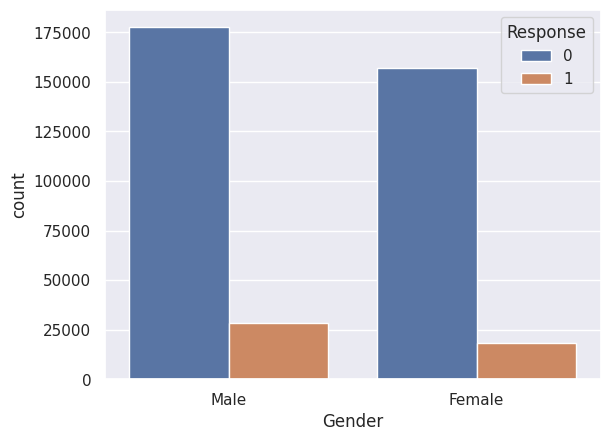

Le statistiche dei due generi sono molto simili, con il 90% circa di persone che non assicurano il veicolo e il 10% che lo assicura.
Questa statistica riflette lo sbilanciamento della variabile Response stessa.


Count of Driving_License [%]
---------------------------
Driving_License
1    99.8
0     0.2
Name: proportion, dtype: float64

Count of Driving_License vs Response
---------------------------
Response            0     1
Driving_License            
0                95.0   5.0
1                87.7  12.3


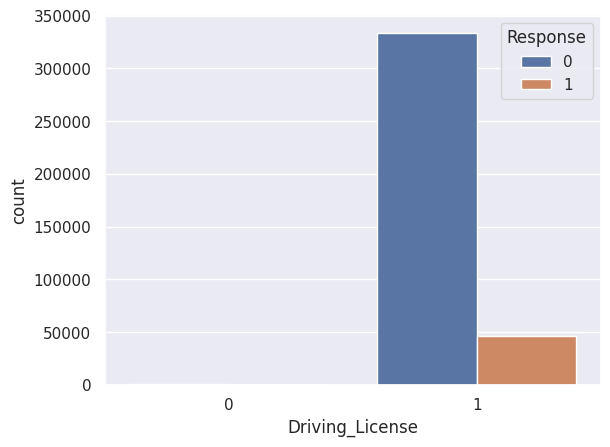

Come già osservato e come logico ci sono pochissime persone senza la patente di guida che richiedono un'assicurazione.
Tra quelli con la patente di guida, invece, anche in questo caso si riflette la statistica di 88% casi di risposta positiva all'assicurazione e 12% negativa.


Count of Vehicle_Damage [%]
---------------------------
Vehicle_Damage
Yes    50.5
No     49.5
Name: proportion, dtype: float64

Count of Vehicle_Damage vs Response
---------------------------
Response           0     1
Vehicle_Damage            
No              99.5   0.5
Yes             76.2  23.8


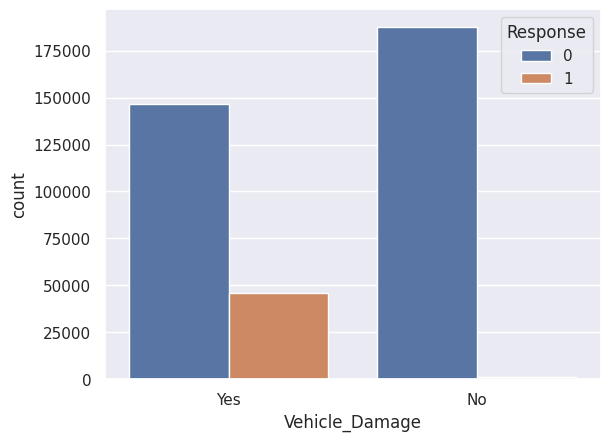

Si osserva che raramente persone che non hanno avuto incidenti assicurano il veicolo.
C'è quindi una tendenza da parte di persone con precedenti di incidenti ad accettare la proposta di assicurazione.


Count of Previously_Insured [%]
---------------------------
Previously_Insured
0    54.2
1    45.8
Name: proportion, dtype: float64

Count of Previously_Insured vs Response
---------------------------
Response               0     1
Previously_Insured            
0                   77.5  22.5
1                   99.9   0.1


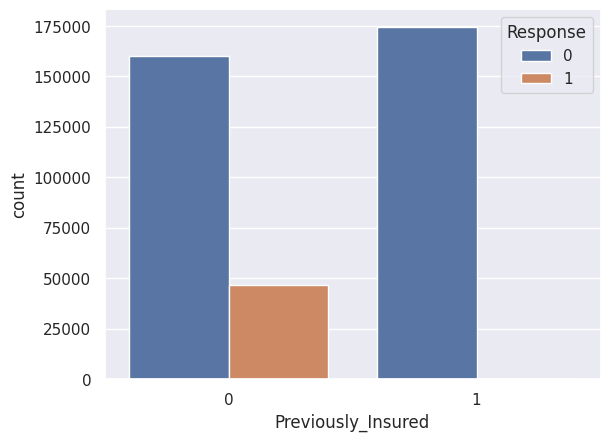

Si osserva che le persone che hanno già un veicolo assicurato raramente ne assicurano un altro (solo lo 0.1% dei casi corrisponde a questa situazione).
In questo caso, quindi, sembrerebbe esserci una dissonanza tra le due variabili per cui chi ha già un veicolo assicurato non accetta un'altra proposta di assicurazione.


Count of Vehicle_Age [%]
---------------------------
Vehicle_Age
1-2 Year     52.6
< 1 Year     43.2
> 2 Years     4.2
Name: proportion, dtype: float64

Count of Vehicle_Age vs Response
---------------------------
Response        0     1
Vehicle_Age            
1-2 Year     82.6  17.4
< 1 Year     95.6   4.4
> 2 Years    70.6  29.4


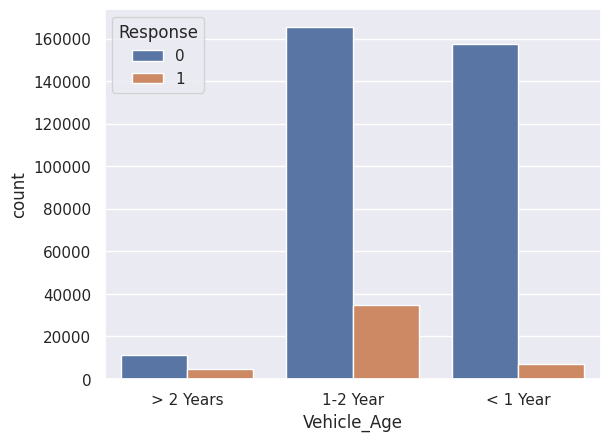

Si osserva che la maggior parte delle persone ha veicoli di 1-2 anni, mentre sono molto poche quelle con veicoli superiori ai 2 anni.
Tuttavia, per i possedenti di veicoli superiori a 2 anni c'è la % più alta di assicurati (29%).


In [ ]:
categ_counts_response('Gender')
print('Le statistiche dei due generi sono molto simili, con il 90% circa di persone che non assicurano il veicolo e il 10% che lo assicura.\n' \
'Questa statistica riflette lo sbilanciamento della variabile Response stessa.\n\n')
categ_counts_response('Driving_License')
print("Come già osservato e come logico ci sono pochissime persone senza la patente di guida che richiedono un'assicurazione.\n" \
"Tra quelli con la patente di guida, invece, anche in questo caso si riflette la statistica di 88% casi di risposta positiva all'assicurazione e 12% negativa.\n\n")
categ_counts_response('Vehicle_Damage')
print("Si osserva che raramente persone che non hanno avuto incidenti assicurano il veicolo.\n" \
"C'è quindi una tendenza da parte di persone con precedenti di incidenti ad accettare la proposta di assicurazione.\n\n")
categ_counts_response('Previously_Insured')
print("Si osserva che le persone che hanno già un veicolo assicurato raramente ne assicurano un altro (solo lo 0.1% dei casi corrisponde a questa situazione).\n\
In questo caso, quindi, sembrerebbe esserci una dissonanza tra le due variabili per cui chi ha già un veicolo assicurato non accetta un'altra proposta di assicurazione.\n\n")
categ_counts_response('Vehicle_Age')
print("Si osserva che la maggior parte delle persone ha veicoli di 1-2 anni, mentre sono molto poche quelle con veicoli superiori ai 2 anni.\n\
Tuttavia, per i possedenti di veicoli superiori a 2 anni c'è la % più alta di assicurati (29%).")

Si osserva la dipendenza del premio annuale dalla risposta, suddivisa per età del veicolo, mediante i boxplot.

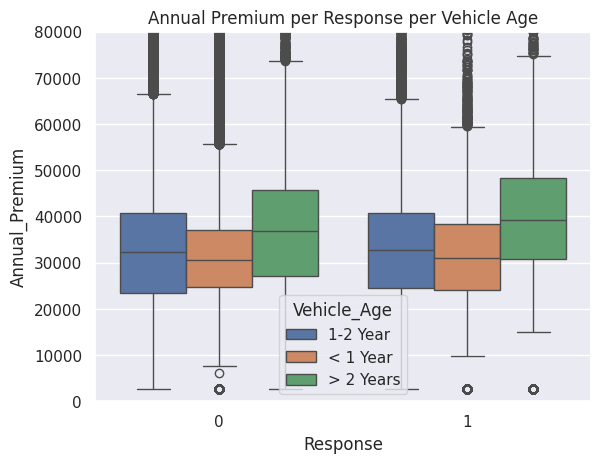

In [ ]:
sns.boxplot(x = df['Response'], y= df['Annual_Premium'], hue = df['Vehicle_Age'])
plt.ylim(0,80000)
plt.title("Annual Premium per Response per Vehicle Age")
plt.show()

Non si osserva una particolare relazione tra il valore del premio annuale e l'accettazione della proposta di cross-sell, tuttavia c'è una tendenza ad un premio maggiore per i veicoli con più di 2 anni.

#### Variabili Region_Code e Policy_Sales_Channel

Si considera la variabile 'Region_Code' e si osservano le frequenze % delle categorie con la seguente tabella

In [ ]:
round((df['Region_Code'].value_counts(normalize=True)*100),1).sort_values(ascending=False).head(10)

,proportion
Region_Code,
28.0,27.9
8.0,8.9
46.0,5.2
41.0,4.8
15.0,3.5
30.0,3.2
29.0,2.9
50.0,2.7
3.0,2.4


Si osserva che la maggior parte delle persone (il 30%) dei clienti proviene dalla regione con codice 28.  
Inoltre, tra tutti gli assicurati, il 42.6% dei clienti proviene da questa regione, come si può osservare nella tabella di contingenza seguente.

In [ ]:
round(pd.crosstab(df['Region_Code'],df['Response'], normalize='columns')*100, 1).sort_values(by=1, ascending=False).head(10)

Response,0,1
Region_Code,,
28.0,25.9,42.6
8.0,9.2,7.0
41.0,4.8,4.8
46.0,5.3,4.4
29.0,2.9,2.9
3.0,2.4,2.5
11.0,2.4,2.2
15.0,3.7,2.1
30.0,3.4,1.9


Si osservano ora le percentuali di frequenza per la variabile Policy_Sales_Channel

In [ ]:
round((df['Policy_Sales_Channel'].value_counts(normalize=True)*100),1).sort_values(ascending=False).head(10)

,proportion
Policy_Sales_Channel,
152.0,35.4
26.0,20.9
124.0,19.4
160.0,5.7
156.0,2.8
122.0,2.6
157.0,1.8
154.0,1.6
151.0,1.0


La maggior parte dei clienti è stata contattata mediante i canali 152, 26 e 124.  
Dalla tabella di contingenza seguente, si osserva però che la maggior parte dei clienti che ha accettato la proposta di cross-selling deriva dai canali 26 e 124 (insieme il 65% dei clienti assicurati), mentre il canale 152 rappresenta l'8%.

In [ ]:
round(pd.crosstab(df['Policy_Sales_Channel'],df['Response'], normalize='columns')*100, 1).sort_values(by=1, ascending=False).head(10)

Response,0,1
Policy_Sales_Channel,,
26.0,19.1,34.0
124.0,17.9,30.0
152.0,39.2,8.3
156.0,2.5,4.9
157.0,1.5,3.8
122.0,2.5,3.7
154.0,1.4,3.2
163.0,0.6,1.9
160.0,6.4,1.0


Dato che queste due variabili hanno un numero elevato di categorie, ma la maggior parte dei campioni sono relativi a poche di esse, si decide di lasciare solo le prime tre o quattro categorie più frequenti e con maggiori casi di collegamento con la risposta e raggruppare tutto il resto in una categoria "altro".  

Quindi, per la variabile Region_Code, si tengono le seguenti categorie: 28, 8, 46, 41.  
Per la variabile Policy_Sales_Channel si tengono le seguenti categorie: 26, 124, 152.

In [ ]:
cat_region_code = [28.0, 8.0, 46.0, 41.0]
cat_sales_channel = [26.0, 124.0, 152.0]

df['Region_Code_mapped'] = mapping_cat(df['Region_Code'], cat_region_code)
df['Policy_Sales_Channel_mapped'] = mapping_cat(df['Policy_Sales_Channel'], cat_sales_channel)

## Codifica delle variabili categoriche

Sono da codificare le seguenti variabili: Gender, Vehicle_Age, Vehicle_Damage, Region_Code, Policy_Sales_Channel

Per Gender e Vehicle_Damage si effettua un Label Encoding, per Vehicle_Age un Ordinal Encoding, mentre per Region_Code e Policy_Sales_Channel si effettua il OneHot Encoding

In [ ]:
gender_map = {'Male': 0, 'Female':1}
damage_map = {'No': 0, 'Yes': 1}
age_map = {'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}

df['Gender'] = df['Gender'].map(gender_map)
df['Vehicle_Damage'] = df['Vehicle_Damage'].map(damage_map)
df['Vehicle_Age'] = df['Vehicle_Age'].map(age_map)

In [ ]:
df = pd.get_dummies(df,columns=['Region_Code_mapped', 'Policy_Sales_Channel_mapped'], dtype=int, prefix = {'Region_Code_mapped': 'RC', 'Policy_Sales_Channel_mapped': 'PSC'})
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,RC_8.0,RC_28.0,RC_41.0,RC_46.0,RC_altro,PSC_26.0,PSC_124.0,PSC_152.0,PSC_altro
0,0,44,1,28.0,0,2,1,40454.0,26.0,217,1,0,1,0,0,0,1,0,0,0
1,0,76,1,3.0,0,1,0,33536.0,26.0,183,0,0,0,0,0,1,1,0,0,0
2,0,47,1,28.0,0,2,1,38294.0,26.0,27,1,0,1,0,0,0,1,0,0,0
3,0,21,1,11.0,1,0,0,28619.0,152.0,203,0,0,0,0,0,1,0,0,1,0
4,1,29,1,41.0,1,0,0,27496.0,152.0,39,0,0,0,1,0,0,0,0,1,0


## Train-test split e scaling

In [ ]:
#defining x and y
x = df.drop(['Response','Region_Code','Policy_Sales_Channel'], axis=1)
y = df['Response']

In [ ]:
random_seed = 42

In [ ]:
#splitting in train and test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=random_seed, stratify=y)

Si scalano con lo standard scaler solo le variabili quantitative, ovvero Age, Vehicle_Age, Annual_Premium e Vintage, mentre si lasciano intatte le variabili categoriche codificate.

In [ ]:
var_to_scale = ['Age', 'Vehicle_Age', 'Annual_Premium', 'Vintage']
ss = StandardScaler()

#splitting numeric and categorical variables for train and test sets
train_num = x_train[var_to_scale]
train_cat = x_train.drop(columns=var_to_scale)

test_num = x_test[var_to_scale]
test_cat = x_test.drop(columns=var_to_scale)

#scaling the numeric variables and construction of the dataframe
train_num_scaled = pd.DataFrame(ss.fit_transform(train_num), columns=var_to_scale, index=x_train.index)
test_num_scaled = pd.DataFrame(ss.transform(test_num), columns=var_to_scale, index=x_test.index)

#concat the dataframe
x_train_scaled = pd.concat([train_num_scaled, train_cat], axis=1)
x_test_scaled = pd.concat([test_num_scaled, test_cat], axis=1)

#column reordering
x_train_scaled = x_train_scaled[x_train.columns]
x_test_scaled = x_test_scaled[x_test.columns]

## Modello 1: regressione logistica senza modificatori

In [ ]:
lr = LogisticRegression()
lr.fit(x_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred_train = lr.predict(x_train_scaled)
y_proba_train = lr.predict_proba(x_train_scaled)
y_pred_test = lr.predict(x_test_scaled)
y_proba_test =  lr.predict_proba(x_test_scaled)

print("TRAIN REPORT")
print(classification_report(y_train, y_pred_train))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    234079
           1       0.30      0.00      0.00     32697

    accuracy                           0.88    266776
   macro avg       0.59      0.50      0.47    266776
weighted avg       0.81      0.88      0.82    266776

TEST REPORT
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    100320
           1       0.33      0.00      0.00     14013

    accuracy                           0.88    114333
   macro avg       0.61      0.50      0.47    114333
weighted avg       0.81      0.88      0.82    114333



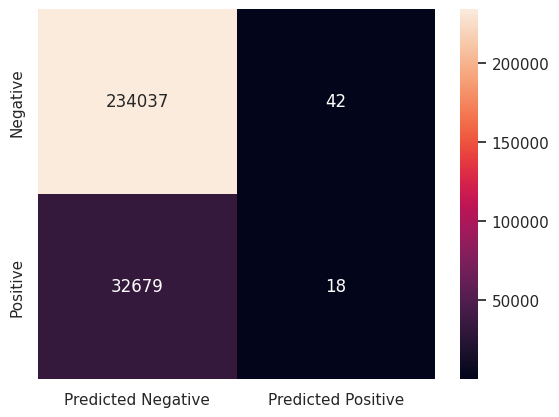

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

In questo modello si osserva una accuratezza elevata, ovvero dell'88%, tuttavia la recall è praticamente nulla e la precision molto bassa. Questa è probabilmente la conseguenza del dataset molto sbilanciato, infatti, come si osserva dalla matrice di confusione, l'accuratezza è elevata perchè il modello predice bene i negativi, mentre i positivi vengono quasi tutti predetti come negativi, generando un elevato numero di falsi negativi.  
Con un modello di questo tipo, un gran numero di persone potenzialmente interessate verrebbero classificate come non interessate, quindi si potrebbe evitare di chiamarle per proporre l'assicurazione e perdere così parecchi potenziali clienti.

Si cerca quindi di ottimizzare il modello per ovviare allo sbilanciamento di classe e migliorare la recall, in modo tale da individuare meglio i clienti potenzialmente interessati alla proposta.

## Modello 2: Oversampling

Si effettua l'oversampling sul train set per generare dati sintetici sulla classe meno rappresentata.

In [ ]:
oversample = RandomOverSampler(sampling_strategy='minority', random_state=random_seed)

x_over, y_over = oversample.fit_resample(x_train_scaled, y_train)

In [ ]:
lr = LogisticRegression()

lr.fit(x_over, y_over)

y_pred_over = lr.predict(x_over)
y_proba_over = lr.predict_proba(x_over)
y_pred_test = lr.predict(x_test)
y_proba_test =  lr.predict_proba(x_test)

print("TRAIN REPORT")
print(classification_report(y_over, y_pred_over))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.94      0.61      0.74    234079
           1       0.71      0.96      0.82    234079

    accuracy                           0.78    468158
   macro avg       0.82      0.78      0.78    468158
weighted avg       0.82      0.78      0.78    468158

TEST REPORT
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    100320
           1       0.00      0.00      0.00     14013

    accuracy                           0.88    114333
   macro avg       0.44      0.50      0.47    114333
weighted avg       0.77      0.88      0.82    114333



Utilizzando l'oversampling, si osserva un miglioramento delle performance (ad aeccezione dell'accuratezza) sul train set, tuttavia esse calano drasticamente sul test set, ad indicare che il modello è fortemente affetto da overfitting.

## Modello 3: Undersampling

Si effettua l'undersampling sulla classe più rappresentata per bilancaire il set di train

In [ ]:
undersample = RandomUnderSampler(sampling_strategy='majority', random_state=random_seed)

x_under, y_under = undersample.fit_resample(x_train_scaled, y_train)


In [ ]:
lr = LogisticRegression()

lr.fit(x_under, y_under)

LogisticRegression()

In [ ]:
y_pred_under = lr.predict(x_under)
y_proba_under = lr.predict_proba(x_under)
y_pred_test = lr.predict(x_test)
y_proba_test =  lr.predict_proba(x_test)

print("TRAIN REPORT")
print(classification_report(y_under, y_pred_under))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.94      0.61      0.74     32697
           1       0.71      0.96      0.82     32697

    accuracy                           0.79     65394
   macro avg       0.83      0.79      0.78     65394
weighted avg       0.83      0.79      0.78     65394

TEST REPORT
              precision    recall  f1-score   support

           0       0.88      1.00      0.93    100320
           1       0.00      0.00      0.00     14013

    accuracy                           0.88    114333
   macro avg       0.44      0.50      0.47    114333
weighted avg       0.77      0.88      0.82    114333



Anche in questo caso, nonostante il miglioramento in fase di test dell'accurateza, le metriche quali precision e recall sono praticamente nulle, rendendo il modello inutilizzabile per lo scopo.

## Modello4: Regressione logistica pesata

Si effettua la regressione logistica inserendo il parametro "class_weight" = 'balanced', in modo tale da effettuarla applicando un peso alle classi e poter bilanciare il fitting.

In [ ]:
lr = LogisticRegression(class_weight='balanced')

lr.fit(x_train_scaled, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
y_pred_train = lr.predict(x_train_scaled)
y_proba_train = lr.predict_proba(x_train_scaled)
y_pred_test = lr.predict(x_test_scaled)
y_proba_test =  lr.predict_proba(x_test_scaled)

print("TRAIN REPORT")
print(classification_report(y_train, y_pred_train))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))


TRAIN REPORT
              precision    recall  f1-score   support

           0       0.99      0.61      0.76    234079
           1       0.26      0.96      0.40     32697

    accuracy                           0.65    266776
   macro avg       0.62      0.78      0.58    266776
weighted avg       0.90      0.65      0.71    266776

TEST REPORT
              precision    recall  f1-score   support

           0       0.99      0.61      0.76    100320
           1       0.26      0.96      0.41     14013

    accuracy                           0.66    114333
   macro avg       0.62      0.79      0.58    114333
weighted avg       0.90      0.66      0.71    114333



In questo modo si ottiene un modello non affetto da overfitting, infatti le performance rimangono praticamente invariate passando da train set a test set.  
Si osserva inoltre una recall molto elevata, ad indicare che viene individuato correttamente il 96% delle persone effettivamente positive e quindi potenzialmente interessate alla proposta di cross-selling.  
La precision rimane invece bassa, del 26%, ad indicare che c'è un numero elevato di falsi positivi, come si può osservare anche dalle matrici di confusione seguenti.  
Questa è probabilmente la causa del valore di accuratezza del 66%.

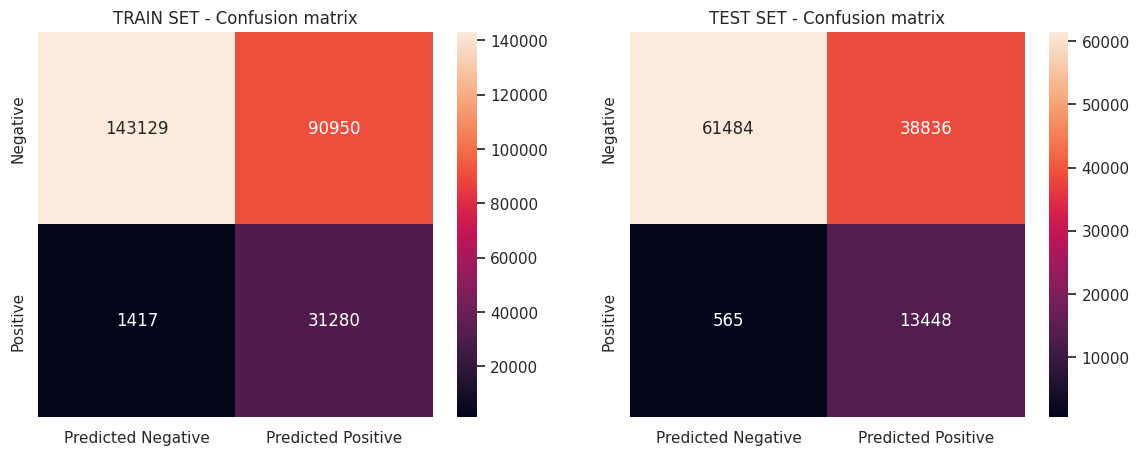

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plot_confusion_matrix(y_train, y_pred_train)
plt.title('TRAIN SET - Confusion matrix')

plt.subplot(1,2,2)
plot_confusion_matrix(y_test, y_pred_test)
plt.title('TEST SET - Confusion matrix')

plt.show()


## Modello5: Selezione variabili

Si prova ad effettuare il modello di regressione logistica 'balanced' inserendo solo le variabili risultate più influenti per la risposta.  
In particolare, si scelgono le variabili Vehicle_Damage, Previously_Insured, Vehicle_Age e Annual_Premium.

In [ ]:
selected_variables = ['Vehicle_Damage', 'Previously_Insured', 'Vehicle_Age', 'Annual_Premium']

x_selected_train = x_train_scaled[selected_variables]
x_selected_test  = x_test_scaled[selected_variables]

In [ ]:
x_selected_train

,Vehicle_Damage,Previously_Insured,Vehicle_Age,Annual_Premium
223531,0,1,0.686683,0.230147
337977,0,1,0.686683,0.080331
320307,0,0,0.686683,-1.622764
261303,0,1,-1.075324,-1.622764
71160,0,1,-1.075324,0.019813
...,...,...,...,...
149107,1,0,-1.075324,1.026224
378816,1,1,-1.075324,-0.440252
91744,0,0,-1.075324,1.653454
48700,0,1,0.686683,-0.096175


In [ ]:
lr = LogisticRegression(class_weight='balanced')

lr.fit(x_selected_train, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
y_pred_train = lr.predict(x_selected_train)
y_proba_train = lr.predict_proba(x_selected_train)
y_pred_test = lr.predict(x_selected_test)
y_proba_test =  lr.predict_proba(x_selected_test)

print("TRAIN REPORT")
print(classification_report(y_train, y_pred_train))
print("TEST REPORT")
print(classification_report(y_test, y_pred_test))


TRAIN REPORT
              precision    recall  f1-score   support

           0       0.99      0.59      0.74    234079
           1       0.25      0.98      0.40     32697

    accuracy                           0.64    266776
   macro avg       0.62      0.78      0.57    266776
weighted avg       0.90      0.64      0.70    266776

TEST REPORT
              precision    recall  f1-score   support

           0       0.99      0.59      0.74    100320
           1       0.25      0.98      0.40     14013

    accuracy                           0.64    114333
   macro avg       0.62      0.78      0.57    114333
weighted avg       0.90      0.64      0.70    114333



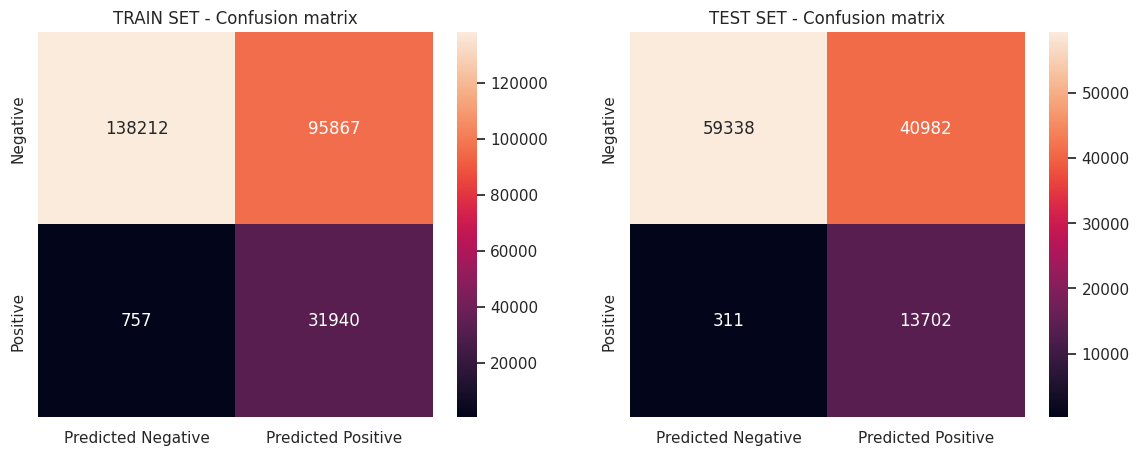

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plot_confusion_matrix(y_train, y_pred_train)
plt.title('TRAIN SET - Confusion matrix')

plt.subplot(1,2,2)
plot_confusion_matrix(y_test, y_pred_test)
plt.title('TEST SET - Confusion matrix')

plt.show()

Con questo modello la recall è ulteriormente migliorata del 2%, salendo al 98%, senza impattare in maniera troppo elevata sulle altre metriche, che sono scese solo di 1 o 2 punti percentuali.

La recall del modello, che rappresenta il numero di positivi correttamente individuati e quindi clienti che potrebbero essere interessati, è già molto alta (del 98%).  
La precision invece è piuttosto bassa (25%), indicando che dei classificati positivi, solamente il 25% sono corretti, quindi sono presenti molti falsi positivi, ovvero clienti che il modello classifica come interessati che invece non lo sono.

Si cerca dunque una soglia che provi ad ottimizzare un po' la precision ma senza intaccare troppo la recall, che si vuole comunque mantenere alta, dato che rappresenta proprio il quantitativo di clienti interessati correttamente individuati e quindi la presenza di pochi falsi negativi.

In [ ]:
soglie = np.arange(0,1.02, 0.02)

results = []

for soglia in soglie:

    y_proba_train_converted = np.where(y_proba_train[:,1]>= soglia, 1, 0)
    y_proba_test_converted = np.where(y_proba_test[:,1]>= soglia, 1, 0)

    results.append({'soglia': soglia,
        'Accuracy_train': accuracy_score(y_train,y_proba_train_converted),
        'Precision_train': precision_score(y_train,y_proba_train_converted, zero_division=0),
        'Recall_train': recall_score(y_train,y_proba_train_converted),
        'f1_score_train': f1_score(y_train,y_proba_train_converted),
        'Accuracy_test': accuracy_score(y_test,y_proba_test_converted),
        'Precision_test': precision_score(y_test,y_proba_test_converted, zero_division=0),
        'Recall_test': recall_score(y_test,y_proba_test_converted),
        'f1_score_test': f1_score(y_test,y_proba_test_converted)
    })

df_results = pd.DataFrame(results)


Si ordinano i risultati in base all'f1_score del set di test, che bilancia i parametri di recall e precision.

In [ ]:
round(df_results.sort_values('f1_score_test', ascending=False), 6).head(10)

,soglia,Accuracy_train,Precision_train,Recall_train,f1_score_train,Accuracy_test,Precision_test,Recall_test,f1_score_test
35,0.70,0.717804,0.280235,0.830413,0.419054,0.720133,0.282753,0.835224,0.422481
32,0.64,0.717782,0.280223,0.830443,0.419044,0.720107,0.282743,0.835296,0.422479
34,0.68,0.717804,0.280235,0.830413,0.419054,0.720125,0.282746,0.835224,0.422474
33,0.66,0.717801,0.280232,0.830413,0.419051,0.720125,0.282746,0.835224,0.422474
31,0.62,0.717640,0.280158,0.830749,0.419011,0.719958,0.282659,0.835510,0.422412
30,0.60,0.652139,0.254200,0.950515,0.401125,0.653705,0.255552,0.954185,0.403136
27,0.54,0.637808,0.249908,0.976848,0.397996,0.638836,0.250567,0.977806,0.398911
20,0.40,0.637808,0.249908,0.976848,0.397996,0.638836,0.250567,0.977806,0.398911
24,0.48,0.637808,0.249908,0.976848,0.397996,0.638836,0.250567,0.977806,0.398911
25,0.50,0.637808,0.249908,0.976848,0.397996,0.638836,0.250567,0.977806,0.398911


Si osservano anche le curve ROC del modello

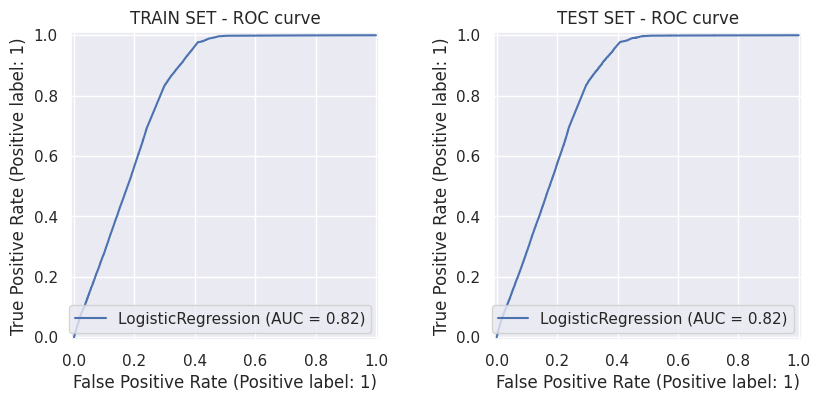

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

RocCurveDisplay.from_estimator(lr,x_selected_train,y_train,ax=ax[0])
ax[0].set_title('TRAIN SET - ROC curve')
RocCurveDisplay.from_estimator(lr, x_selected_test, y_test, ax= ax[1])
ax[1].set_title('TEST SET - ROC curve')
plt.show()


Si può osservare che la soglia che restituisce un f1_score maggiore è a 0.7, tuttavia a questo valore le metriche nel set di test sono le seguenti:

- f1_score: 42%
- recall: 83%
- precision: 28%
- accuracy: 72%

Se si confrontano con quelle del modello con soglia a 0.5, si può notare che f1_score e precision aumentano del 2-3% e l'accuracy dell'8%, ma a discapito di un decremento della recall del 14%.  
Si ritiene che perdere il 14% di positivi classificati correttamente per una diminuzione di falsi negativi del solo 3% non sia vantaggioso per il modello e per l'obiettivo dello studio.  
Pertanto, si sceglie di mantenere la soglia a 0.5, infatti, anche selezionando ad esempio quella a 0.6, dove la recall dimuisce solo al 95%, la precision rimarrebbe comuqnue al 25% e l'accuracy migliorerebbe di un solo punto percentuale.  

Si mantiene dunque il modello selezionato con il 98% di recall e con la soglia a 0.5 (Modello5).

## Cross-Validation

Si verifica l'assenza di overfitting del modello scelto mediante cross-validation

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

Si selezionano le sole variabili che erano state scelte per il modello

In [ ]:
x_selected = x[selected_variables]
x_selected

,Vehicle_Damage,Previously_Insured,Vehicle_Age,Annual_Premium
0,1,0,2,40454.0
1,0,0,1,33536.0
2,1,0,2,38294.0
3,0,1,0,28619.0
4,0,1,0,27496.0
...,...,...,...,...
381104,0,1,1,30170.0
381105,0,1,0,40016.0
381106,0,1,0,35118.0
381107,1,0,2,44617.0


Si esegue la 5-fold cross-validation, dividendo il dataset x_selected in 5 fold.  
Per ogni fold si effettua la seguente pipeline:  
- si separano le variabili numeriche da quelle categoriche
- si effettua la scalatura sulle variabili numeriche, applicando il fit_transform sul train set e il transform sul test set
- si riuniscono le variabili in unico dataset
- si esegue il modello di regressione logistica 'balanced' sul train set
- si calcolano le metriche di accurateza, recall e precisione per la valutazione delle performances sia sul train sia sul test set

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

train_acc = []
test_acc = []
train_recall = []
test_recall = []
train_prec = []
test_prec = []

for train_index, test_index in kf.split(x):

  x_train_cv, x_test_cv = x.iloc[train_index], x.iloc[test_index]
  y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

  #defining variables to scale
  var_to_scale_cv = ['Vehicle_Age', 'Annual_Premium']

  #splitting in numeric and categorical variables
  train_cv_num = x_train_cv[var_to_scale_cv]
  train_cv_cat = x_train_cv.drop(columns=var_to_scale_cv)

  test_cv_num = x_test_cv[var_to_scale_cv]
  test_cv_cat = x_test_cv.drop(columns=var_to_scale_cv)

  #scaling numeric variables
  ss = StandardScaler()
  train_cv_num_scaled = pd.DataFrame(ss.fit_transform(train_cv_num), columns=var_to_scale_cv, index= x_train_cv.index)
  test_cv_num_scaled = pd.DataFrame(ss.transform(test_cv_num), columns=var_to_scale_cv, index=x_test_cv.index)

  #concat the dataframes
  x_train_cv_scaled = pd.concat([train_cv_num_scaled, train_cv_cat], axis=1)
  x_test_cv_scaled = pd.concat([test_cv_num_scaled, test_cv_cat], axis=1)

  #reordering the columns
  x_train_cv_scaled = x_train_cv_scaled[x_train_cv.columns]
  x_test_cv_scaled = x_test_cv_scaled[x_test_cv.columns]

  #fitting the model
  lr = LogisticRegression(class_weight = 'balanced')
  lr.fit(x_train_cv_scaled, y_train_cv)

  #calculating the metrics for train and test sets
  acc_train = accuracy_score(y_train_cv, lr.predict(x_train_cv_scaled))
  acc_test = accuracy_score(y_test_cv, lr.predict(x_test_cv_scaled))
  recall_train = recall_score(y_train_cv, lr.predict(x_train_cv_scaled))
  recall_test = recall_score(y_test_cv, lr.predict(x_test_cv_scaled))
  prec_train = precision_score(y_train_cv, lr.predict(x_train_cv_scaled))
  prec_test = precision_score(y_test_cv, lr.predict(x_test_cv_scaled))

  train_acc.append(acc_train)
  test_acc.append(acc_test)
  train_recall.append(recall_train)
  test_recall.append(recall_test)
  train_prec.append(prec_train)
  test_prec.append(prec_test)

#creating a dictionary with the cv results
cv_results = {
      "train_accuracy":np.array(train_acc),
      "test_accuracy":np.array(test_acc),
      "train_recall": np.array(train_recall),
      "test_recall": np.array(test_recall),
      "train_precision": np.array(train_prec),
      "test_precision": np.array(test_prec)
    }

In [ ]:
cv_results

{'train_accuracy': array([0.66949722, 0.65697783, 0.6513528 , 0.66478728, 0.67095786]),
 'test_accuracy': array([0.67338826, 0.65780221, 0.64964184, 0.6647687 , 0.66837223]),
 'train_recall': array([0.93895716, 0.95204325, 0.96041327, 0.94336208, 0.93850561]),
 'test_recall': array([0.93909482, 0.95172857, 0.95753557, 0.94747209, 0.93865555]),
 'train_precision': array([0.26172112, 0.25710796, 0.25502306, 0.26154459, 0.2634205 ]),
 'test_precision': array([0.26889771, 0.25755996, 0.25388542, 0.25668544, 0.26228872])}

Si calcolano le medie delle metriche nei 5 fold e si costruisce la seguente tabella riassuntiva



In [ ]:
cv_results_mean = pd.DataFrame()
cv_results_mean['Metrica'] = ['Accuracy', 'Recall', 'Precision']
cv_results_mean['Train_cv_results'] = [cv_results['train_accuracy'].mean(), cv_results['train_recall'].mean(), cv_results['train_precision'].mean()]
cv_results_mean['Test_cv_results'] = [cv_results['test_accuracy'].mean(), cv_results['test_recall'].mean(), cv_results['test_precision'].mean()]
cv_results_mean = round(cv_results_mean, 4)
cv_results_mean

,Metrica,Train_cv_results,Test_cv_results
0,Accuracy,0.6627,0.6628
1,Recall,0.9467,0.9469
2,Precision,0.2598,0.2599


Dai risultati si conferma l'assenza di overfitting del modello scelto in quanto le performances rimangono simili in tutti i train e test set.  
Il modello può dunque considerarsi valido.

## Conclusioni

È stato costruito un modello di regressione logistica in grado di individuare i clienti potenzialmente interessati ad una proposta di cross-selling assicurativo.  
Il modello è particolarmente adatto a non perdere clienti potenzialmente interessati, a costo di includere erroneamente alcuni clienti che potrebbero non esserlo.  
In particolare, dall'analisi è emerso che i clienti maggiormente interessati potrebbero essere quelli con auto superiori a 2 anni che non hanno già un veicolo assicurato e/o che hanno avuto incidenti in precedenza. Inoltre, si consiglia di continuare ad investire in particolare sui canali di comunicazione 26 e 124, e sulla regione con codice 28.